In [11]:
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover

def clean_smiles(
    smiles: str,
    remove_hs: bool = True,
    strip_stereochem: bool = False,
    strip_salts: bool = True,
) -> str:
    """Applies preprocessing to SMILES strings, seeking the 'parent' SMILES

    Note that this is different from simply _neutralizing_ the input SMILES - we attempt to get the parent molecule, analogous to a molecular skeleton.
    This is adapted in part from https://rdkit.org/docs/Cookbook.html#neutralizing-molecules

    Args:
        smiles (str): input SMILES
        remove_hs (bool, optional): Removes hydrogens. Defaults to True.
        strip_stereochem (bool, optional): Remove R/S and cis/trans stereochemistry. Defaults to False.
        strip_salts (bool, optional): Remove salt ions. Defaults to True.

    Returns:
        str: cleaned SMILES
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        assert mol is not None, f"Could not parse SMILES {smiles}"
        if remove_hs:
            mol = Chem.RemoveHs(mol)
        if strip_stereochem:
            Chem.RemoveStereochemistry(mol)
        if strip_salts:
            remover = SaltRemover()  # use default saltremover
            mol = remover.StripMol(mol)  # strip salts

        pattern = Chem.MolFromSmarts("[+1!h0!$([*]~[-1,-2,-3,-4]),-1!$([*]~[+1,+2,+3,+4])]")
        at_matches = mol.GetSubstructMatches(pattern)
        at_matches_list = [y[0] for y in at_matches]
        if len(at_matches_list) > 0:
            for at_idx in at_matches_list:
                atom = mol.GetAtomWithIdx(at_idx)
                chg = atom.GetFormalCharge()
                hcount = atom.GetTotalNumHs()
                atom.SetFormalCharge(0)
                atom.SetNumExplicitHs(hcount - chg)
                atom.UpdatePropertyCache()
        out_smi = Chem.MolToSmiles(mol, kekuleSmiles=True)  # this also canonicalizes the input
        assert len(out_smi) > 0, f"Could not convert molecule to SMILES {smiles}"
        return out_smi
    except Exception as e:
        print(f"Failed to clean SMILES {smiles} due to {e}")
        return None

In [12]:
import pandas as pd

In [13]:
dfs = [
    pd.read_csv("euos25_challenge_train_fluorescence340_450_extended.csv").rename(columns={"Fluorescence": "F340450"}),
    pd.read_csv("euos25_challenge_train_fluorescence480_extended.csv").rename(columns={"Fluorescence": "F480"}),
    pd.read_csv("euos25_challenge_train_transmittance340_extended.csv").rename(columns={"Transmittance (quantitative)": "T340"}),
    pd.read_csv("euos25_challenge_train_transmittance450_extended.csv").rename(columns={"Transmittance (quantitative)": "T450"}),
    pd.read_csv("euos25_challenge_test.csv"),
]

In [15]:
for df in dfs:
    df["clean_smiles"] = df["SMILES"].apply(clean_smiles)

In [38]:
# concat dataframes, keeping only the clean_smiles and target column
train_df = pd.concat(
    [
        dfs[0][["clean_smiles", "F340450"]],
        dfs[1][["clean_smiles", "F480"]],
        dfs[2][["clean_smiles", "T340"]],
        dfs[3][["clean_smiles", "T450"]],
        dfs[4][["clean_smiles"]],
    ],
    ignore_index=True,
).pivot_table(index="clean_smiles", dropna=False, sort=False)

In [39]:
train_df

,F340450,F480,T340,T450
clean_smiles,,,,
COC1=CC=C(N2C(=O)NC(CC(=O)N3CCC(C4=CC=CC=C4)CC3)C2=O)C=C1,0.0,0.0,99.9,99.9
O=C(CCCC(=O)N1CCOC(C2=CC=CC=C2)C1)N1CCOC(C2=CC=CC=C2)C1,0.0,0.0,99.9,99.9
CSCC[C@@H](CO)NC(=O)C1=CN(C)C2=C(F)C=C(F)C=C2C1=O,0.0,0.0,80.8,99.9
O=C(CC1NC(=O)N(CCC2=CC=CC=C2)C1=O)N[C@H](CO)CC1=CC=CC=C1,0.0,0.0,99.9,99.9
CC(=O)NC1=CC=CC(N2C(=O)NC(CCC(=O)N3CCN(C4=CC=CC=C4)CC3)C2=O)=C1,0.0,0.0,99.9,99.9
...,...,...,...,...
CC1=CN(C[C@H]2CCCN2CC2=NOC(C(C)C)=N2)N=C1,NaN,NaN,NaN,NaN
C1=CC=C(C2=NOC(CCCSC3=CN=NN3)=N2)C=C1,NaN,NaN,NaN,NaN
C[C@@H](C1CC1)N(C)S(=O)(=O)CCN1C=NC2=CC=CC=C21,NaN,NaN,NaN,NaN


In [ ]:
#log transform the continuous targets
from scipy.special import logit

train_df["T340_transform"] = logit(train_df["T340"] / 100)
train_df["T450_transform"] = logit(train_df["T450"] / 100)

array([[<Axes: title={'center': 'F340450'}>,
        <Axes: title={'center': 'F480'}>],
       [<Axes: title={'center': 'T340'}>,
        <Axes: title={'center': 'T450'}>],
       [<Axes: title={'center': 'T340_transform'}>,
        <Axes: title={'center': 'T450_transform'}>]], dtype=object)

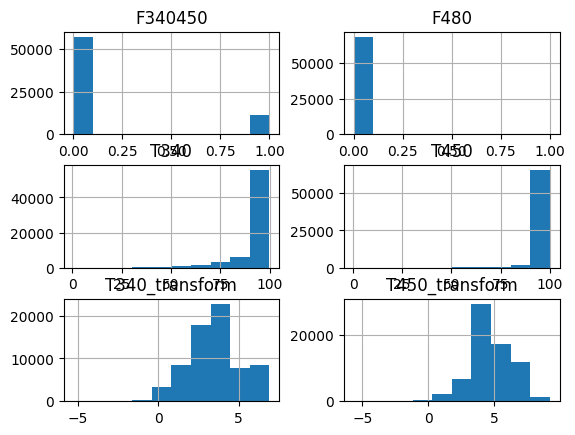

In [46]:
train_df.hist()

In [47]:
train_df.describe()

,F340450,F480,T340,T450,T340_transform,T450_transform
count,68972.000000,68972.000000,68972.000000,68972.000000,68972.000000,68972.000000
mean,0.166865,0.002378,92.766840,97.277073,3.533820,4.685843
std,0.372858,0.048705,11.148679,6.399481,1.697344,1.567006
min,0.000000,0.000000,0.500000,0.350000,-5.293305,-5.651486
25%,0.000000,0.000000,92.800000,97.650000,2.556366,3.726974
50%,0.000000,0.000000,97.000000,98.950000,3.476099,4.545825
75%,0.000000,0.000000,98.700000,99.640000,4.329721,5.623215
max,1.000000,1.000000,99.900000,99.990000,6.906755,9.210240


In [73]:
from mordred import Calculator, descriptors
from rdkit.Chem import MolFromSmiles

calc = Calculator(descriptors, ignore_3D=True)

In [74]:
desc_df = calc.pandas(map(MolFromSmiles, train_df.index.tolist()), nmols=train_df.shape[0])
desc_df.index = train_df.index.tolist()

100%|██████████| 98392/98392 [11:44<00:00, 139.69it/s] 


In [75]:
desc_df = desc_df.fill_missing()

/home/jwburns/.conda/envs/eous25/lib/python3.11/site-packages/mordred/_base/pandas_module.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  t[t.applymap(is_missing)] = value


In [76]:
desc_df.to_parquet("pretraining.parquet", index=True)

In [77]:
target_cols = ['F340450', 'F480', 'T340', 'T450', 'T340_transform', 'T450_transform']
train_df[target_cols].dropna(subset=target_cols, how="all").to_csv("training.csv", index_label="clean_smiles")

In [78]:
train_df[train_df[target_cols].isna().all(axis=1)][[]].to_csv("testing.csv", index_label="clean_smiles")